In [1]:
import sys
sys.path.append('..')

import numpy as np
import hmm
import emission_model
import matplotlib.pyplot as plt

# Test on synthetic HMM with Gaussian emissions


In [2]:
mu_th    = [0.05,  -0.08,  0.00]
sigma_th = [0.008,  0.015,  0.025]
A_th = np.array([[0.9, 0.08, 0.02],
                  [0.03, 0.95, 0.02],
                  [0.05, 0.05, 0.90]])



def generate_gaussian_data(T=2000, seed=42, A= A_th, mu=mu_th, sigma=sigma_th):

    rng = np.random.default_rng(seed)
    # True params: 3 regimes (bull, bear, volatile)
    

    states, obs = [], []
    s = 0
    for _ in range(T):
        states.append(s)
        # Gaussian sample
        x = np.random.normal(mu[s], sigma[s])
        obs.append(x)
        s = rng.choice(3, p=A[s])
    return np.array(obs), np.array(states)

In [3]:
obs, states = generate_gaussian_data(T=20000)
obs=obs.reshape((1, obs.shape[0]))

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   2.,
          0.,   2.,   1.,   5.,   5.,   6.,   5.,   4.,   7.,   7.,  10.,
         12.,  14.,  14.,  25.,  13.,  21.,  22.,  32.,  28.,  33.,  49.,
         48.,  52.,  54.,  68.,  61.,  63.,  74.,  75.,  84., 110.,  93.,
        133., 130., 135., 154., 152., 167., 194., 172., 216., 191., 203.,
        210., 254., 237., 219., 253., 243., 273., 289., 280., 246., 268.,
        284., 237., 287., 242., 279., 235., 243., 242., 240., 255., 227.,
        195., 190., 177., 175., 163., 135., 129., 142., 129., 116., 108.,
        122., 115., 105.,  86.,  77.,  78.,  60.,  52.,  53.,  54.,  44.,
         43.,  46.,  32.,  41.,  36.,  23.,  30.,  26.,  25.,  23.,  25.,
         22.,  17.,  22.,  17.,  19.,  24.,  27.,  24.,  23.,  28.,  19.,
         19.,  28.,  20.,  22.,  23.,  29.,  24.,  29.,  29.,  34.,  33.,
         34.,  44.,  39.,  36.,  35.,  38.,  40.,  48.,  55.,  48.,  46.,
         43.,  46.,  55.,  53.,  41., 

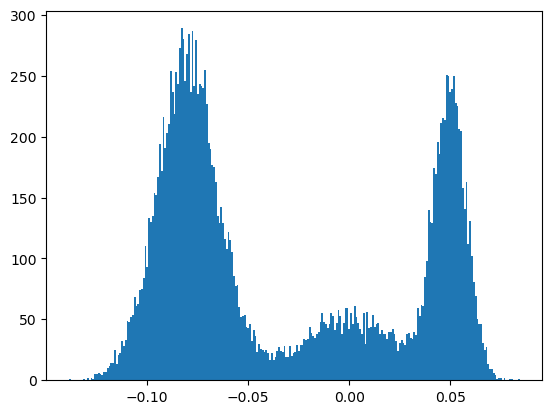

In [4]:
plt.hist(obs[0, :], bins=250)

In [5]:
from tqdm import tqdm
### Gaussian emissions
err_t = []
final_err = []
HMM_list = []
N_cycles = 10

for i in range(N_cycles):
    
    pi = np.random.rand((3))
    pi = pi/np.sum(pi)
    
    params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)],  # state 1
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05)]  # state 2
    ])
    
    emission = emission_model.Gaussian_Emission(3, obs, params)
    HMM = hmm.Hmm(3, emission, pi, A=None, eps=1e-8)
    
    err_t.append(HMM.Baum_Welch(obs, N_max=35))
    final_err.append(err_t[i][-1])
    HMM_list.append(HMM)
    

############################################################################################################################################################################
Start learning: Baum-Welch expectation - maximization algorithm 
Iteration    1  |  -logL =       0.036202  |  -ΔL/L = 100.000000%
Iteration    2  |  -logL =      -1.389106  |  -ΔL/L = -3937.080603%
Iteration    3  |  -logL =      -1.409107  |  -ΔL/L = 1.439845%
Iteration    4  |  -logL =      -1.417813  |  -ΔL/L = 0.617802%
Iteration    5  |  -logL =      -1.445040  |  -ΔL/L = 1.920351%
Iteration    6  |  -logL =      -1.576426  |  -ΔL/L = 9.092183%
Iteration    7  |  -logL =      -2.022549  |  -ΔL/L = 28.299692%
Iteration    8  |  -logL =      -2.291022  |  -ΔL/L = 13.273965%
Iteration    9  |  -logL =      -2.374585  |  -ΔL/L = 3.647420%
Iteration   10  |  -logL =      -2.480135  |  -ΔL/L = 4.445008%
Iteration   11  |  -logL =      -2.543183  |  -ΔL/L = 2.542101%
Iteration   12  |  -logL =      -2.566912  |  -ΔL/

In [9]:
# choose the HMM with the lowest -logL
HMM = HMM_list[np.argmin(np.array(final_err))]

HMM.emission.params = HMM.emission.params[np.argsort(HMM.emission.params[:, 0]), :]
th_sort = np.argsort(np.array(mu_th))
mu_th = np.array(mu_th)[th_sort]
sigma_th = np.array(sigma_th)[th_sort]

print(r'Synthetic Gaussian generating processes ($\mu$, $\sigma$:) ')
print(' ')
print([(float(mu_th[i]), float(sigma_th[i])) for i in range(len(mu_th))])
print(' ')
print(r'Learned Gaussian generating processes: HMM.emission.gauss_params')
print(' ')
print([(float(np.round(HMM.emission.params[i, 0], 4)), (float(np.round(HMM.emission.params[i, 1], 4)))) for i in range(HMM.emission.params.shape[0])])


#print(r'Transition matrix generating synthetic data $A_{th}$ =' A_th)
#print(r'Best learned transition matrix $A_{hmm}$ = ', HMM.A)

Synthetic Gaussian generating processes ($\mu$, $\sigma$:) 
 
[(-0.08, 0.015), (0.0, 0.025), (0.05, 0.008)]
 
Learned Gaussian generating processes: HMM.emission.gauss_params
 
[(-0.08, 0.0151), (0.0008, 0.0246), (0.0499, 0.0079)]


In [10]:
np.argsort(np.array(mu_th))

array([0, 1, 2])

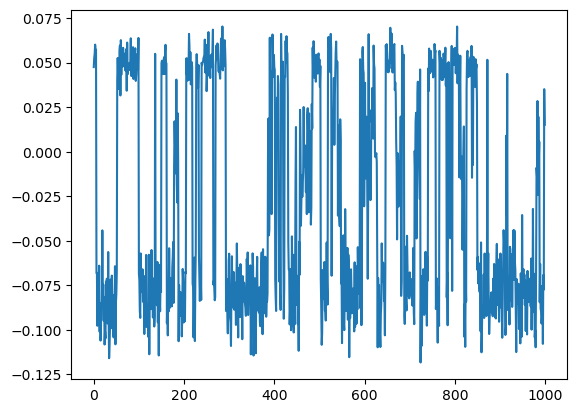

In [8]:
plt.plot(obs[0, :1000])